In [6]:
from lsst.daf.butler import Butler
from lsst.afw.display import Display
import lsst.afw.display as afwDisplay
import firefly_client.plot as ffplt

In [11]:
butler = Butler("/user/p5_group/pranshu/ci_hsc_gen3/DATA", collections=["HSC/runs/ci_hsc"])

In [3]:
refs = butler.query_datasets("deepCoadd")
print(len(refs))

2


In [4]:
coadd = butler.get(refs[0])

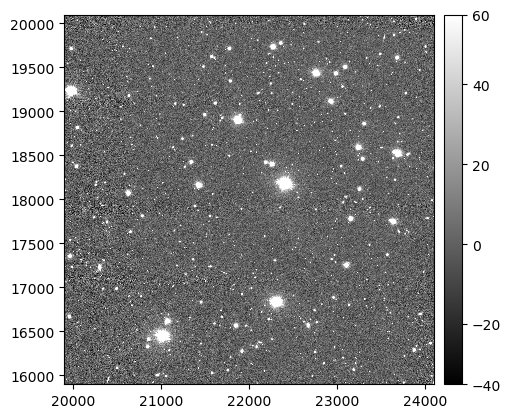

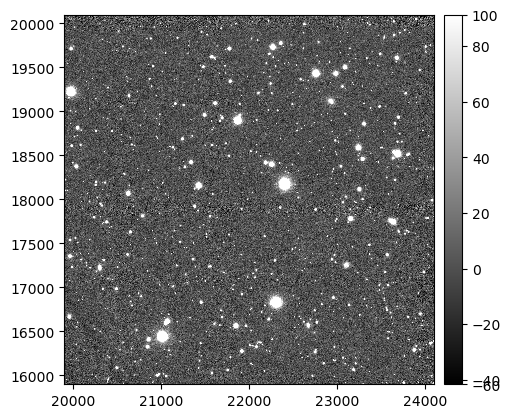

In [5]:
%matplotlib inline

for ref_id, ref in enumerate(refs):
    coadd = butler.get(ref)
    disp = Display(frame=ref_id, backend="matplotlib")
    disp.scale("linear","zscale")
    disp.mtv(coadd.image)
    disp.show()

In [13]:
coadd.image

lsst.afw.image._image.ImageF=[[ 3.0738244e+00  3.2599514e+01 -4.7968507e-01 ...  7.3546307e+02
   1.0282340e+03  1.3821156e+03]
 [-3.5141070e+00 -1.7512798e+01  1.2449190e+01 ...  7.8430823e+02
   9.7519873e+02  1.3957739e+03]
 [ 3.6167524e+00  1.9930868e+01  3.7093903e+01 ...  8.0929132e+02
   1.0120261e+03  1.3613204e+03]
 ...
 [-9.1989164e+00 -1.6982582e+01 -2.6466672e+00 ... -4.9790222e+01
  -2.3979504e+00  3.3250717e+01]
 [ 1.9410875e+01  7.9079866e+00 -2.8602396e+01 ...  1.4461438e+01
  -2.5881188e+00 -2.0677074e+01]
 [ 2.4044855e+01  2.3380011e+01  8.3583489e-02 ... -7.2468414e+00
   3.3886032e+01  6.2107315e+00]], bbox=(minimum=(19900, 15900), maximum=(24099, 20099))

Difference Image

In [19]:
butler.get_dataset_type('goodSeeingDiff_differenceExp')

DatasetType('goodSeeingDiff_differenceExp', {band, instrument, day_obs, detector, physical_filter, visit}, ExposureF)

In [21]:
butler.get_dataset_type('goodSeeingDiff_differenceExp').dimensions.required

{instrument, detector, visit}

In [23]:
diff_refs = butler.query_datasets("goodSeeingDiff_differenceExp")
print(len(diff_refs))

30


In [24]:
diff = butler.get(diff_refs[0])

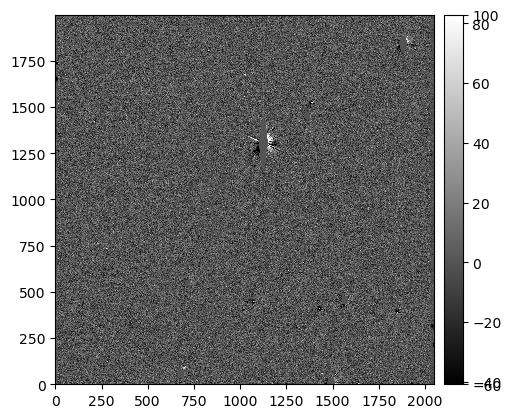

In [42]:
%matplotlib inline

# for ref_id, ref in enumerate(diff_refs):
#     diff_img = butler.get(ref)
#     disp = Display(frame=ref_id, backend="matplotlib")
#     disp.scale("linear","zscale")
#     disp.mtv(diff_img.image)
#     disp.show()

from lsst.geom import Point2I, Extent2I, Box2I

ymin = 0
ymax = 2000

for ref_id, ref in enumerate(diff_refs):
    if ref_id != 5:
        continue

    diff_img = butler.get(ref)

    width = diff_img.getWidth()
    height = ymax - ymin

    bbox = Box2I(Point2I(0, ymin), Extent2I(width, height))
    subimg = diff_img[bbox]

    disp = Display(frame=0, backend="matplotlib")
    disp.scale("linear", "zscale")
    disp.mtv(subimg.image)
    disp.show()

Good Seeing Coadd

In [43]:
from lsst.geom import Point2I, Extent2I, Box2I

ymin = 0
ymax = 2000

ref = diff_refs[5] 
diff_img = butler.get(ref)

bbox = Box2I(
    Point2I(0, ymin),
    Extent2I(diff_img.getWidth(), ymax - ymin)
)

subimg = diff_img[bbox]

subimg.writeFits("diff_cutout_no5.fits")

In [34]:
butler.get_dataset_type('goodSeeingCoadd')

DatasetType('goodSeeingCoadd', {band, skymap, tract, patch}, ExposureF)

In [35]:
butler.get_dataset_type('goodSeeingCoadd').dimensions.required

{band, skymap, tract, patch}

In [36]:
goodseeing_refs = butler.query_datasets("goodSeeingCoadd")
print(len(goodseeing_refs))

2


In [37]:
diff = butler.get(goodseeing_refs[0])

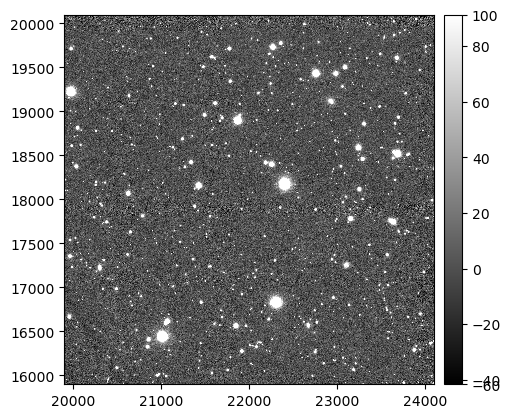

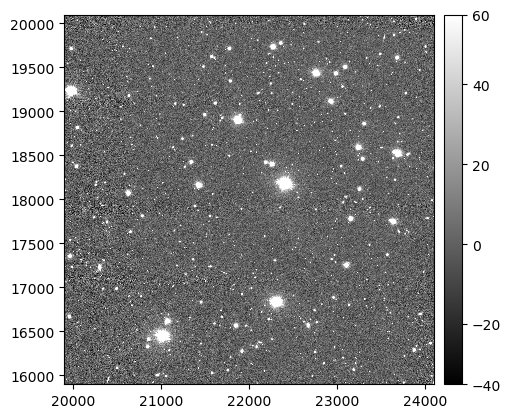

In [38]:
%matplotlib inline

for ref_id, ref in enumerate(goodseeing_refs):
    diff_img = butler.get(ref)
    disp = Display(frame=ref_id, backend="matplotlib")
    disp.scale("linear","zscale")
    disp.mtv(diff_img.image)
    disp.show()

Catalogs

In [1]:
import lsst.daf.base as dafBase
from lsst.daf.butler import Butler
import lsst.afw.image as afw_image
import lsst.afw.display as afw_display
import lsst.afw.table as afwTable
import lsst.geom as geom
from lsst.meas.algorithms.detection import SourceDetectionTask
from lsst.meas.deblender import SourceDeblendTask
from lsst.meas.base import SingleFrameMeasurementTask
import matplotlib.pyplot as plt
import numpy as np

In [2]:
butler = Butler("/user/p5_group/pranshu/ci_hsc_gen3/DATA", collections=["HSC/runs/ci_hsc"])

In [3]:
refs = butler.query_datasets("deepCoadd")
print(len(refs))

2


In [4]:
refs[0].dataId

{band: 'r', skymap: 'discrete/ci_hsc', tract: 0, patch: 69}

In [5]:
obj = butler.get("objectTable", tract=0, patch=69)

Plot 1

In [112]:
row_num = 70


flux_r = []
apertures_r = []

for i in range(80):
    col_name = 'r_ap'+str(i).zfill(2)+'Flux'
    flag_col = 'r_ap'+str(i).zfill(2)+'Flux_flag'
    if col_name in obj.columns:
        if not obj[row_num][flag_col]:
            flux_r.append(obj[row_num][col_name])
            apertures_r.append(i)
    # print(col_name)
    # obj[30]['i_ap09Flux']

flux_i = []
apertures_i = []

for i in range(80):
    col_name = 'i_ap'+str(i).zfill(2)+'Flux'
    flag_col = 'i_ap'+str(i).zfill(2)+'Flux_flag'
    if col_name in obj.columns:
        if not obj[row_num][flag_col]:
            flux_i.append(obj[row_num][col_name])
            apertures_i.append(i)


flux_g = []
apertures_g = []

for i in range(80):
    col_name = 'g_ap'+str(i).zfill(2)+'Flux'
    flag_col = 'g_ap'+str(i).zfill(2)+'Flux_flag'
    if col_name in obj.columns:
        if not obj[row_num][flag_col]:
            flux_g.append(obj[row_num][col_name])
            apertures_g.append(i)

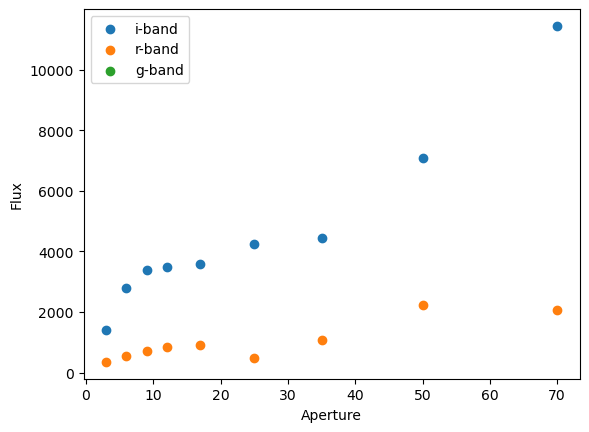

In [113]:
import matplotlib.pyplot as plt

plt.scatter(apertures_i, flux_i, label='i-band')
plt.scatter(apertures_r, flux_r, label='r-band')
plt.scatter(apertures_g, flux_g, label='g-band')

plt.xlabel('Aperture')
plt.ylabel('Flux')
plt.savefig('curve70.png')
plt.legend()
plt.show()

In [143]:
row_num = 40


SNR_r = []
apertures_r = []

for i in range(80):
    col_name_S = 'r_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'r_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'r_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            # print('done')
            SNR_r.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_r.append(i)
    # print(col_name)
    # obj[30]['i_ap09Flux']

SNR_i = []
apertures_i = []

for i in range(80):
    col_name_S = 'i_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'i_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'i_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            SNR_i.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_i.append(i)


SNR_g = []
apertures_g = []

for i in range(80):
    col_name_S = 'g_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'g_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'g_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            SNR_g.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_g.append(i)

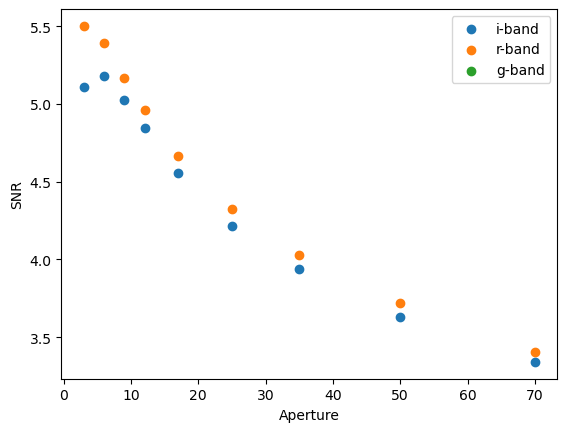

In [153]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(apertures_i, np.log(SNR_i), label='i-band')
plt.scatter(apertures_r, np.log(SNR_r), label='r-band')
plt.scatter(apertures_g, np.log(SNR_g), label='g-band')

plt.xlabel('Aperture')
plt.ylabel('SNR')
plt.savefig('SNR40.png')
plt.legend()
plt.show()

In [147]:
row_num = 40


SNR_r = []
apertures_r = []

for i in range(80):
    col_name_S = 'r_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'r_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'r_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    SNR_psf_r = obj[obj['i_calib_psf_used']][row_num]['r_psfFlux']/obj[obj['i_calib_psf_used']][row_num]['r_psfFluxErr']
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            # print('done')
            SNR_r.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_r.append(i)
    # print(col_name)
    # obj[30]['i_ap09Flux']

SNR_i = []
apertures_i = []

for i in range(80):
    col_name_S = 'i_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'i_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'i_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    SNR_psf_i = obj[obj['i_calib_psf_used']][row_num]['i_psfFlux']/obj[obj['i_calib_psf_used']][row_num]['i_psfFluxErr']
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            SNR_i.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_i.append(i)


SNR_g = []
apertures_g = []

for i in range(80):
    col_name_S = 'g_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'g_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'g_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    SNR_psf_g = obj[obj['i_calib_psf_used']][row_num]['g_psfFlux']/obj[obj['i_calib_psf_used']][row_num]['g_psfFluxErr']
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            SNR_g.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_g.append(i)

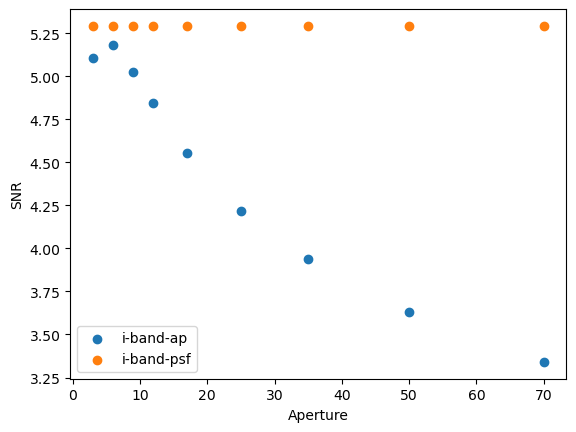

In [154]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(apertures_i, np.log(SNR_i), label='i-band-ap')
plt.scatter(apertures_i, [np.log(SNR_psf_i)]*len(apertures_i), label='i-band-psf')
# plt.scatter(apertures_r, SNR_r, label='r-band-ap')
# plt.scatter(apertures_g, SNR_g, label='g-band-ap')

plt.xlabel('Aperture')
plt.ylabel('SNR')
plt.savefig('SNR40_hzline.png')
plt.legend()
plt.show()

In [156]:
obj[obj['i_calib_psf_used']]

tract,patch,i_ra,i_dec,i_raErr,i_decErr,i_ra_dec_Cov,i_psfFlux,i_psfFluxErr,i_free_psfFlux,i_free_psfFluxErr,i_free_psfFlux_flag,i_gaapPsfFlux,i_gaapPsfFluxErr,i_gaap0p7Flux,i_gaap0p7FluxErr,i_gaap1p0Flux,i_gaap1p0FluxErr,i_ixx,i_iyy,i_ixy,i_i_flag,i_ixxPSF,i_iyyPSF,i_ixyPSF,i_iPSF_flag,i_moments_g1,i_moments_g2,i_moments_trace,i_moments_flag,i_moments_psf_g1,i_moments_psf_g2,i_moments_psf_trace,i_moments_psf_flag,i_moments_psf_debiased_g1,i_moments_psf_debiased_g2,i_moments_psf_debiased_trace,i_moments_psf_debiased_flag,i_kronRad,i_kronFlux,i_kronFluxErr,i_ap03Flux,i_ap03FluxErr,i_ap03Flux_flag,i_ap06Flux,i_ap06FluxErr,i_ap06Flux_flag,i_ap09Flux,i_ap09FluxErr,i_ap09Flux_flag,i_ap12Flux,i_ap12FluxErr,i_ap12Flux_flag,i_ap17Flux,i_ap17FluxErr,i_ap17Flux_flag,i_ap25Flux,i_ap25FluxErr,i_ap25Flux_flag,i_ap35Flux,i_ap35FluxErr,i_ap35Flux_flag,i_ap50Flux,i_ap50FluxErr,i_ap50Flux_flag,i_ap70Flux,i_ap70FluxErr,i_ap70Flux_flag,i_extendedness,i_sizeExtendedness,i_blendedness,i_cModel_dev_reff_major,i_cModel_dev_reff_minor,i_cModel_dev_theta,i_cModel_exp_reff_major,i_cModel_exp_reff_minor,i_cModel_exp_theta,i_cModel_chi2,i_cModel_devFlux,i_cModel_devFluxErr,i_cModel_expFlux,i_cModel_expFluxErr,i_cModelFlux,i_cModelFluxErr,i_cModelFlux_inner,i_cModel_fracDev,i_free_cModelFlux,i_free_cModelFluxErr,i_free_cModelFlux_inner,i_free_cModelFlux_flag,i_free_cModel_fracDev,i_free_cModel_devFlux,i_free_cModel_devFluxErr,i_free_cModel_expFlux,i_free_cModel_expFluxErr,i_hsmShapeRegauss_e1,i_hsmShapeRegauss_e2,i_hsmShapeRegauss_sigma,i_hsmShapeRegauss_flag,i_hsm_moments_30,i_hsm_momentsPsf_30,i_hsm_moments_21,i_hsm_momentsPsf_21,i_hsm_moments_12,i_hsm_momentsPsf_12,i_hsm_moments_03,i_hsm_momentsPsf_03,i_hsm_moments_40,i_hsm_momentsPsf_40,i_hsm_moments_31,i_hsm_momentsPsf_31,i_hsm_moments_22,i_hsm_momentsPsf_22,i_hsm_moments_13,i_hsm_momentsPsf_13,i_hsm_moments_04,i_hsm_momentsPsf_04,i_hsm_moments_flag,i_hsm_momentsPsf_flag,i_inputCount,i_psfModel_TwoGaussian_gauss1_sigma_x,i_psfModel_TwoGaussian_gauss1_sigma_y,i_psfModel_TwoGaussian_gauss1_rho,i_psfModel_TwoGaussian_gauss1_fluxfrac,i_psfModel_TwoGaussian_gauss2_sigma_x,i_psfModel_TwoGaussian_gauss2_sigma_y,i_psfModel_TwoGaussian_gauss2_rho,i_psfModel_TwoGaussian_n_iter,i_psfModel_TwoGaussian_chi2_reduced,i_psfModel_TwoGaussian_unknown_flag,i_psfModel_TwoGaussian_no_inputs_flag,i_inputCount_flag,i_inputCount_flag_noInputs,i_psfFlux_area,i_psfFlux_flag,i_psfFlux_flag_apCorr,i_psfFlux_flag_edge,i_psfFlux_flag_noGoodPixels,i_cModel_flag,i_cModel_flag_apCorr,i_gaapFlux_flag,i_gaapFlux_flag_edge,i_blendedness_flag,i_pixelFlags_bad,i_pixelFlags_clipped,i_pixelFlags_clippedCenter,i_pixelFlags_cr,i_pixelFlags_crCenter,i_pixelFlags_edge,i_pixelFlags_inexact_psf,i_pixelFlags_inexact_psfCenter,i_pixelFlags_interpolated,i_pixelFlags_interpolatedCenter,i_pixelFlags_nodata,i_pixelFlags_offimage,i_pixelFlags_saturated,i_pixelFlags_saturatedCenter,i_pixelFlags_sensor_edge,i_pixelFlags_sensor_edgeCenter,i_pixelFlags_suspect,i_pixelFlags_suspectCenter,i_extendedness_flag,i_sizeExtendedness_flag,i_invalidPsfFlag,i_calib_astrometry_used,i_calib_photometry_used,i_calib_psf_candidate,i_calib_psf_reserved,i_calib_psf_used,i_deblend_blendedness,i_deblend_dataCoverage,i_deblend_fluxOverlap,i_deblend_fluxOverlapFraction,i_deblend_zeroFlux,i_apFlux_flag,i_apFlux_flag_apertureTruncated,i_apFlux_flag_sincCoeffsTruncated,i_centroid_flag,i_kronFlux_flag,i_kronFlux_flag_bad_radius,i_kronFlux_flag_bad_shape,i_kronFlux_flag_bad_shape_no_psf,i_kronFlux_flag_edge,i_kronFlux_flag_no_fallback_radius,i_kronFlux_flag_no_minimum_radius,i_kronFlux_flag_small_radius,i_kronFlux_flag_used_minimum_radius,i_kronFlux_flag_used_psf_radius,r_ra,r_dec,r_raErr,r_decErr,r_ra_dec_Cov,r_psfFlux,r_psfFluxErr,r_free_psfFlux,r_free_psfFluxErr,r_free_psfFlux_flag,r_gaapPsfFlux,r_gaapPsfFluxErr,r_gaap0p7Flux,r_gaap0p7FluxErr,r_gaap1p0Flux,r_gaap1p0FluxErr,r_ixx,r_iyy,r_ixy,r_i_flag,r_ixxPSF,r_iyyPSF,r_ixyPSF,r_iPSF_flag,r_moments_g1,r_moments_g2,r_moments_trace,

Plot 3

In [158]:
row_num = 40


SNR_r = []
apertures_r = []

for i in range(80):
    col_name_S = 'r_ap'+str(i).zfill(2)+'Flux'
    col_name_N = 'r_ap'+str(i).zfill(2)+'FluxErr'
    flag_col_1 = 'r_ap'+str(i).zfill(2)+'Flux_flag'
    flag_col_2 = 'i_calib_psf_used'
    SNR_psf_r = obj[obj['i_calib_psf_used']][row_num]['r_psfFlux']/obj[obj['i_calib_psf_used']][row_num]['r_psfFluxErr']
    SNR_cModel_r = obj[obj['i_calib_psf_used']][row_num]['r_cModelFlux']/obj[obj['i_calib_psf_used']][row_num]['r_cModelFluxErr']
    SNR_sersic_r = obj[obj['i_calib_psf_used']][row_num]['r_sersicFlux']/obj[obj['i_calib_psf_used']][row_num]['r_sersicFluxErr']
    if col_name_S in obj.columns:
        if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
            # print('done')
            SNR_r.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
            apertures_r.append(i)
    # print(col_name)
    # obj[30]['i_ap09Flux']

# SNR_i = []
# apertures_i = []

# for i in range(80):
#     col_name_S = 'i_ap'+str(i).zfill(2)+'Flux'
#     col_name_N = 'i_ap'+str(i).zfill(2)+'FluxErr'
#     flag_col_1 = 'i_ap'+str(i).zfill(2)+'Flux_flag'
#     flag_col_2 = 'i_calib_psf_used'
#     SNR_psf_i = obj[obj['i_calib_psf_used']][row_num]['i_psfFlux']/obj[obj['i_calib_psf_used']][row_num]['i_psfFluxErr']
#     if col_name_S in obj.columns:
#         if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
#             SNR_i.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
#             apertures_i.append(i)


# SNR_g = []
# apertures_g = []

# for i in range(80):
#     col_name_S = 'g_ap'+str(i).zfill(2)+'Flux'
#     col_name_N = 'g_ap'+str(i).zfill(2)+'FluxErr'
#     flag_col_1 = 'g_ap'+str(i).zfill(2)+'Flux_flag'
#     flag_col_2 = 'i_calib_psf_used'
#     SNR_psf_g = obj[obj['i_calib_psf_used']][row_num]['g_psfFlux']/obj[obj['i_calib_psf_used']][row_num]['g_psfFluxErr']
#     if col_name_S in obj.columns:
#         if (not obj[obj['i_calib_psf_used']][row_num][flag_col_1]) and (obj[obj['i_calib_psf_used']][row_num][flag_col_2]):
#             SNR_g.append(obj[obj['i_calib_psf_used']][row_num][col_name_S]/obj[obj['i_calib_psf_used']][row_num][col_name_N])
#             apertures_g.append(i)

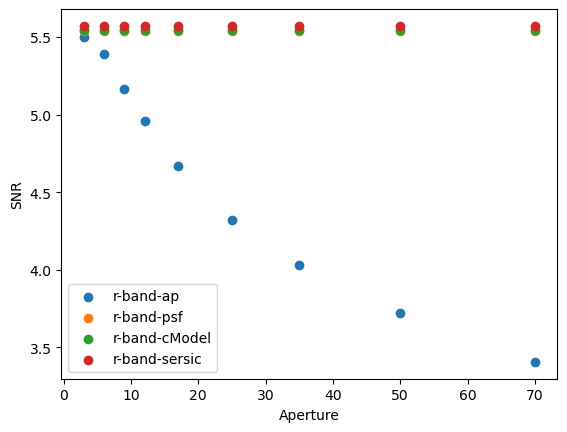

In [160]:
import matplotlib.pyplot as plt
import numpy as np

plt.scatter(apertures_r, np.log(SNR_r), label='r-band-ap')
plt.scatter(apertures_r, [np.log(SNR_psf_r)]*len(apertures_r), label='r-band-psf')
plt.scatter(apertures_r, [np.log(SNR_cModel_r)]*len(apertures_r), label='r-band-cModel')
plt.scatter(apertures_r, [np.log(SNR_sersic_r)]*len(apertures_r), label='r-band-sersic')
# plt.scatter(apertures_r, SNR_r, label='r-band-ap')
# plt.scatter(apertures_g, SNR_g, label='g-band-ap')

plt.xlabel('Aperture')
plt.ylabel('SNR')
plt.savefig('SNRr_cmodel_sersic_psf_ap.png')
plt.legend()
plt.show()

In [21]:
ratio = []
psf_flux = []

for row in obj[obj['i_calib_psf_used']]:
    ratio.append(row['i_sersicFlux']/row['i_psfFlux'])
    psf_flux.append(row['i_psfFlux'])

/tmp/ipykernel_1401097/1574643192.py:1: UserWarning: Warning: converting a masked element to nan.
  plt.scatter(np.log(psf_flux), np.log(ratio), label='sersic - psf')


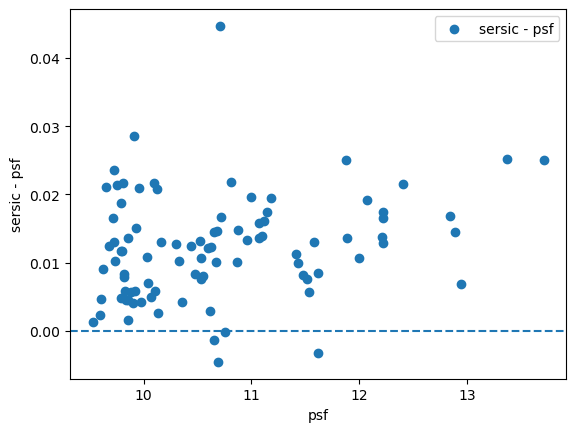

In [23]:
plt.scatter(np.log(psf_flux), np.log(ratio), label='sersic - psf')
plt.axhline(0, linestyle="--")
plt.xlabel('psf')
plt.ylabel('sersic - psf')
plt.savefig('sersic_psf_v_psf.png')
plt.legend()
plt.show()

plot 4

In [24]:
ratio = []
psf_flux = []

for row in obj[obj['i_calib_psf_used'] | obj['i_calib_psf_reserved']]:
    ratio.append(row['i_gaap1p0Flux']/row['i_psfFlux'])
    psf_flux.append(row['i_psfFlux'])

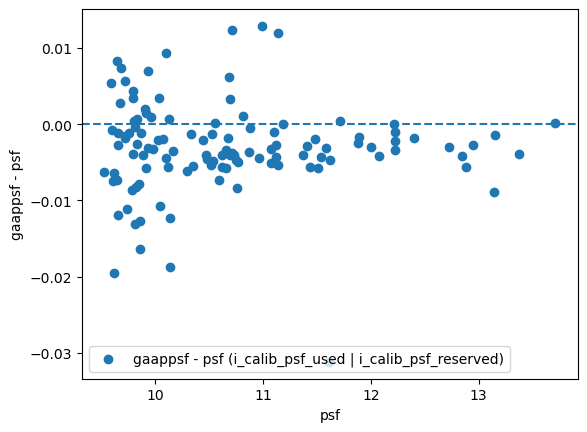

In [25]:
plt.scatter(np.log(psf_flux), np.log(ratio), label='gaappsf - psf (i_calib_psf_used | i_calib_psf_reserved)')
plt.axhline(0, linestyle="--")
plt.xlabel('psf')
plt.ylabel('gaappsf - psf')
plt.savefig('gaappsf_psf_v_psf.png')
plt.legend()
plt.show()

In [26]:
ratio = []
psf_flux = []

for row in obj[obj['i_extendedness'] == 0]:
    ratio.append(row['i_gaap1p0Flux']/row['i_psfFlux'])
    psf_flux.append(row['i_psfFlux'])

/tmp/ipykernel_1401097/2649748727.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(psf_flux), np.log(ratio), label='gaappsf - psf (extendedness = 0)')


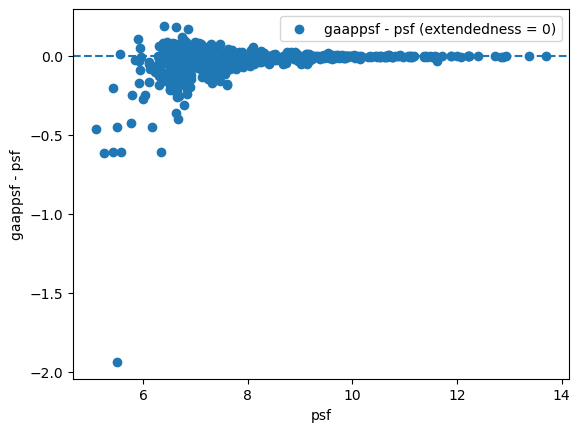

In [27]:
plt.scatter(np.log(psf_flux), np.log(ratio), label='gaappsf - psf (extendedness = 0)')
plt.axhline(0, linestyle="--")
plt.xlabel('psf')
plt.ylabel('gaappsf - psf')
plt.savefig('gaappsf_psf_v_psf.png')
plt.legend()
plt.show()

In [28]:
ratio = []
psf_flux = []

for row in obj[obj['i_extendedness'] == 0]:
    ratio.append(row['i_gaap1p0Flux']/row['i_gaap0p7Flux'])
    psf_flux.append(row['i_gaap0p7Flux'])

/tmp/ipykernel_1401097/1036959012.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(psf_flux), np.log(ratio), label='i_gaap1p0Flux - i_gaap0p7Flux (extendedness = 0)')


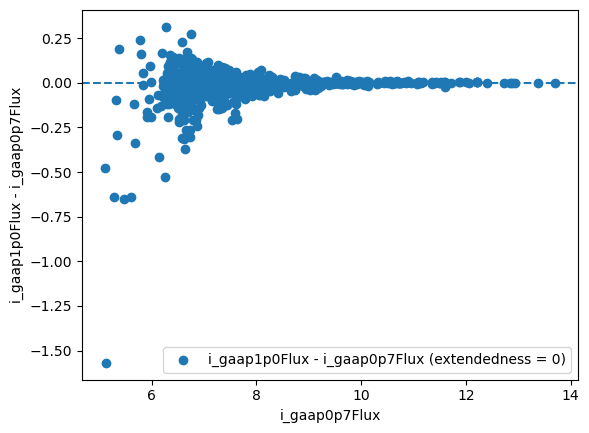

In [29]:
plt.scatter(np.log(psf_flux), np.log(ratio), label='i_gaap1p0Flux - i_gaap0p7Flux (extendedness = 0)')
plt.axhline(0, linestyle="--")
plt.xlabel('i_gaap0p7Flux')
plt.ylabel('i_gaap1p0Flux - i_gaap0p7Flux')
plt.savefig('i_gaap1p0Flux_i_gaap0p7Flux_v_i_gaap0p7Flux.png')
plt.legend()
plt.show()

In [43]:
ratio_con2 = []
psf_flux_con2 = []
ratio_con2_else = []
psf_flux_con2_else = []

for row in obj[obj['i_extendedness'] == 0]:
    ratio_con2.append(row['i_gaap1p0Flux']/row['i_gaap0p7Flux'])
    psf_flux_con2.append(row['i_gaap0p7Flux'])


for row in obj[obj['i_extendedness'] != 0]:
    ratio_con2_else.append(row['i_gaap1p0Flux']/row['i_gaap0p7Flux'])
    psf_flux_con2_else.append(row['i_gaap0p7Flux'])

In [51]:
ratio_con1 = []
psf_flux_con1 = []
ratio_con1_else = []
psf_flux_con1_else = []

for row in obj[obj['i_calib_psf_used'] | obj['i_calib_psf_reserved']]:
    ratio_con1.append(row['i_gaap1p0Flux']/row['i_gaap0p7Flux'])
    psf_flux_con1.append(row['i_gaap0p7Flux'])

for row in obj[~(obj['i_calib_psf_used'] | obj['i_calib_psf_reserved'])]:
    ratio_con1_else.append(row['i_gaap1p0Flux']/row['i_gaap0p7Flux'])
    psf_flux_con1_else.append(row['i_gaap0p7Flux'])

/tmp/ipykernel_1401097/37983034.py:1: RuntimeWarning: invalid value encountered in log10
  plt.scatter(-2.5*np.log10(psf_flux_con2_else), -2.5*np.log10(ratio_con2_else), label='i_gaap1p0Flux - i_gaap0p7Flux (else)', alpha=0.2)
/tmp/ipykernel_1401097/37983034.py:3: RuntimeWarning: invalid value encountered in log10
  plt.scatter(-2.5*np.log10(psf_flux_con2), -2.5*np.log10(ratio_con2), label='i_gaap1p0Flux - i_gaap0p7Flux (extendedness = 0)', alpha=0.2)


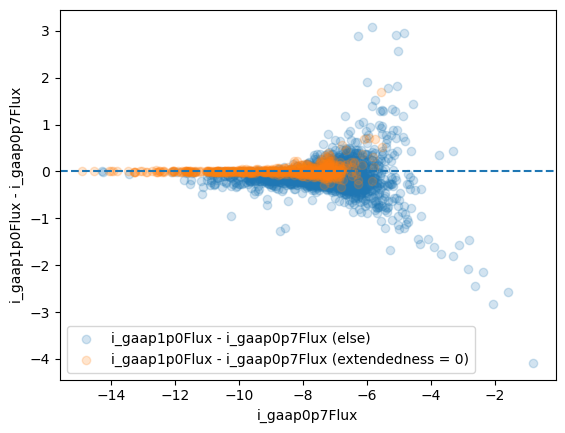

In [47]:
plt.scatter(-2.5*np.log10(psf_flux_con2_else), -2.5*np.log10(ratio_con2_else), label='i_gaap1p0Flux - i_gaap0p7Flux (else)', alpha=0.2)

plt.scatter(-2.5*np.log10(psf_flux_con2), -2.5*np.log10(ratio_con2), label='i_gaap1p0Flux - i_gaap0p7Flux (extendedness = 0)', alpha=0.2)
plt.axhline(0, linestyle="--")
plt.xlabel('i_gaap0p7Flux')
plt.ylabel('i_gaap1p0Flux - i_gaap0p7Flux')
plt.savefig('i_gaap1p0Flux_i_gaap0p7Flux_v_i_gaap0p7Flux_con2_con2else.png')
plt.legend()
plt.show()

/tmp/ipykernel_1401097/1238083925.py:1: RuntimeWarning: invalid value encountered in log10
  plt.scatter(-2.5*np.log10(psf_flux_con1_else), -2.5*np.log10(ratio_con1_else), label='i_gaap1p0Flux - i_gaap0p7Flux (else)', alpha=0.2)


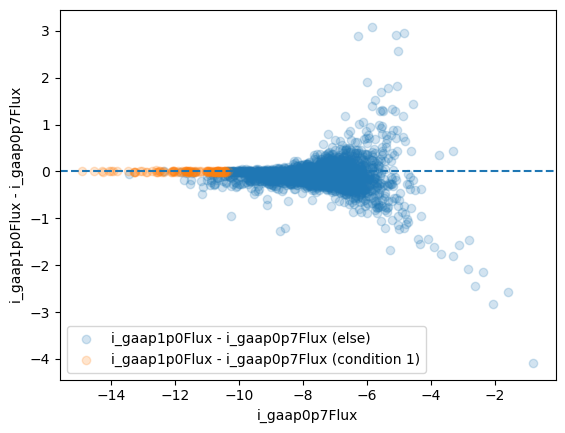

In [53]:
plt.scatter(-2.5*np.log10(psf_flux_con1_else), -2.5*np.log10(ratio_con1_else), label='i_gaap1p0Flux - i_gaap0p7Flux (else)', alpha=0.2)

plt.scatter(-2.5*np.log10(psf_flux_con1), -2.5*np.log10(ratio_con1), label='i_gaap1p0Flux - i_gaap0p7Flux (condition 1)', alpha=0.2)
plt.axhline(0, linestyle="--")
plt.xlabel('i_gaap0p7Flux')
plt.ylabel('i_gaap1p0Flux - i_gaap0p7Flux')
plt.savefig('i_gaap1p0Flux_i_gaap0p7Flux_v_i_gaap0p7Flux_con1_con1else.png')
plt.legend()
plt.show()

plot 5

In [87]:
ratio_1 = []
ratio_2 = []

for row in obj[obj['i_extendedness'] == 0]:
    ratio_1.append(row['i_gaap1p0Flux']/row['r_gaap1p0Flux'])
    ratio_2.append(row['i_ap12Flux']/row['r_ap12Flux'])

/tmp/ipykernel_1401097/2172932724.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(ratio_2), np.log(ratio_1), label='(extendedness = 0)')


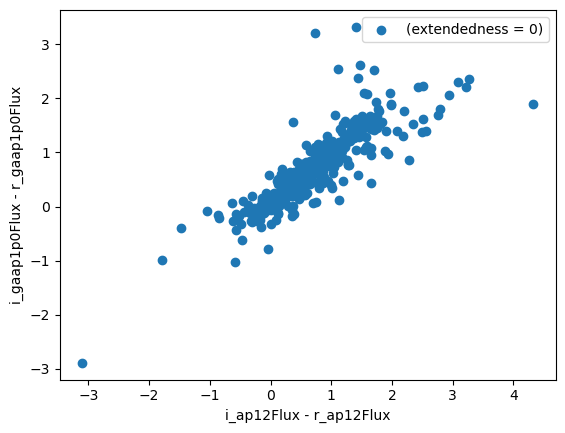

In [88]:
plt.scatter(np.log(ratio_2), np.log(ratio_1), label='(extendedness = 0)')
# plt.axhline(0, linestyle="--")
plt.xlabel('i_ap12Flux - r_ap12Flux')
plt.ylabel('i_gaap1p0Flux - r_gaap1p0Flux')

plt.legend()
plt.savefig('gaapcolor_apcolor_noext.png')
plt.show()

In [89]:
ratio_1 = []
ratio_2 = []

for row in obj[~(obj['i_extendedness'] == 0)]:
    ratio_1.append(row['i_gaap1p0Flux']/row['r_gaap1p0Flux'])
    ratio_2.append(row['i_ap12Flux']/row['r_ap12Flux'])

/tmp/ipykernel_1401097/3981532945.py:1: UserWarning: Warning: converting a masked element to nan.
  plt.scatter(np.log(ratio_2), np.log(ratio_1), label='(extendedness != 0)')
/tmp/ipykernel_1401097/3981532945.py:1: RuntimeWarning: invalid value encountered in log
  plt.scatter(np.log(ratio_2), np.log(ratio_1), label='(extendedness != 0)')


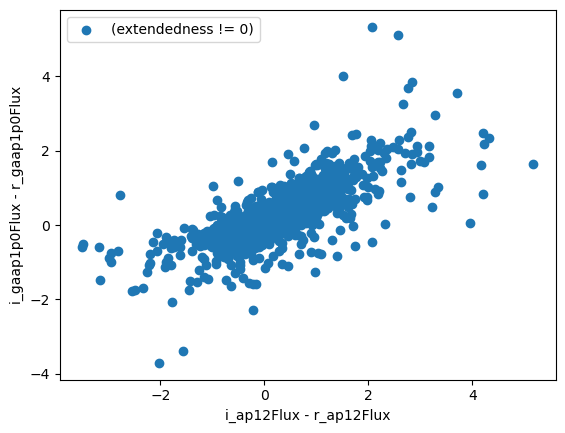

In [90]:
plt.scatter(np.log(ratio_2), np.log(ratio_1), label='(extendedness != 0)')
# plt.axhline(0, linestyle="--")
plt.xlabel('i_ap12Flux - r_ap12Flux')
plt.ylabel('i_gaap1p0Flux - r_gaap1p0Flux')

plt.legend()
plt.savefig('gaapcolor_apcolor_ext.png')
plt.show()

In [91]:
ratio_1 = []
ratio_2 = []

for row in obj[obj['i_calib_psf_used'] | obj['i_calib_psf_reserved']]:
    ratio_1.append(row['i_gaap1p0Flux']/row['r_gaap1p0Flux'])
    ratio_2.append(row['i_ap12Flux']/row['r_ap12Flux'])

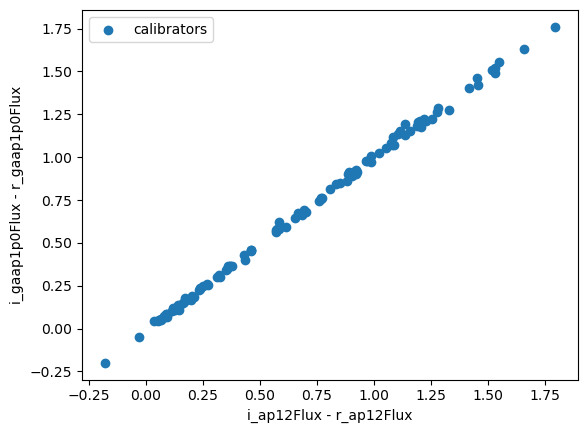

In [92]:
plt.scatter(np.log(ratio_2), np.log(ratio_1), label='calibrators')
# plt.axhline(0, linestyle="--")
plt.xlabel('i_ap12Flux - r_ap12Flux')
plt.ylabel('i_gaap1p0Flux - r_gaap1p0Flux')

plt.legend()
plt.savefig('gaapcolor_apcolor_calibrators.png')
plt.show()